In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units

### Finding regions with both stimulus and prior

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# df_granger = pd.read_csv("../data/processed/granger.csv")
# df_decoding_session_choice = pd.read_parquet("../data/external/choice_stage2.pqt")
# df_decoding_session_stim = pd.read_parquet("../data/external/stimside_stage2.pqt")
# df_decoding_session_feedback = pd.read_parquet("../data/external/feedback_stage2.pqt")
df_decoding_region = pd.read_csv("../data/external/region_info.csv")

In [4]:
df_decoding_region["prior_dec_wf_sig"]

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
274    NaN
275    NaN
276    NaN
277    NaN
278    NaN
Name: prior_dec_wf_sig, Length: 279, dtype: float64

In [5]:
important_columns = [
    "Beryl",
    "Beryl.1",
    "# recordings",
    "# neurons",
    "# good neurons",
    "stim_dec",
    "stim_dec_sig",
    "choice_dec_sig",
    "choice_man_sig",
    "prior_dec_ep",
    "prior_dec_ep_sig",
    "prior_dec_wf_sig",
]

In [6]:
df = df_decoding_region[important_columns]

In [7]:
df_with_signficant_prior = df[(df["prior_dec_wf_sig"] == True) & (df["stim_dec_sig"] == True)]

In [8]:
df_with_signficant_prior.Beryl.values

array(['MOs', 'SSp-ul', 'VISam', 'VISl', 'VISp', 'ACAd', 'PL', 'RSPv',
       'VISa'], dtype=object)

In [9]:
df_with_both = df_with_signficant_prior[df_with_signficant_prior["stim_dec_sig"] == True]

In [10]:
ONE.setup(base_url="https://openalyx.internationalbrainlab.org", silent=True)
one = ONE(password="international")

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [11]:
bwm_df = bwm_query(one)
unit_df = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [50]:
sessionids = unit_df["eid"].unique()

'37e96d0b-5b4b-4c6e-9b29-7edbdc94bbd0'

In [ ]:
count_array = []
for idx in range(10):
    sessionid = sessionids[idx]
    df, mask = load_trials_and_mask(one=one, eid=sessionid, exclude_unbiased=True)
    biased_df = df[mask]
    signed_contrast_index = np.nan_to_num(biased_df.contrastLeft) - np.nan_to_num(
        biased_df.contrastRight
    )
    contrast, counts = np.unique(np.abs(signed_contrast_index), return_counts=True)
    count_array.append(counts)

In [81]:
contrast, counts = np.unique(signed_contrast_index, return_counts=True)

In [82]:
contrast

array([-1.    , -0.25  , -0.125 , -0.0625,  0.    ,  0.0625,  0.125 ,
        0.25  ,  1.    ])

In [83]:
counts

array([40, 39, 39, 38, 38, 33, 36, 38, 35])

In [ ]:
# change_point_indices = biased_df[
#     biased_df["probabilityLeft"] != biased_df["probabilityLeft"].shift(1)
# ].index.tolist()
# change_point_indices

[91, 135, 188, 209, 240, 313, 369, 414, 475, 516, 594, 613]

/var/folders/nr/dw4dxrwd2r3ctns0lnz88jjc0000gn/T/ipykernel_15332/3735847853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biased_df["signed_contrast_index"] = np.where(


In [47]:
np.unique(np.abs(biased_df["signed_contrast_index"]), return_counts=True)

(array([0.    , 0.0625, 0.125 , 0.25  , 1.    ]), array([39, 61, 59, 76, 56]))

In [46]:
25 + 14

39

In [13]:
# cross-ref regions, pids, eids and units; should be fast

In [14]:
# only keep regions of interest

regions_of_interest = df_with_both["Beryl"].unique()

In [15]:
units_regions_of_interest = unit_df[unit_df["Beryl"].isin(regions_of_interest)]

In [16]:
eid_counts = (
    units_regions_of_interest.groupby(["Beryl", "eid"]).size().reset_index(name="count_per_eid")
)

In [17]:
result = eid_counts.groupby("Beryl")["count_per_eid"].mean().reset_index()

In [18]:
# Group by Beryl and eid, and get the counts for each unique pair
# This gives a Series with a MultiIndex
eid_counts = units_regions_of_interest.groupby(["Beryl", "eid"]).size()

# Now, group by Beryl from the multi-indexed Series and calculate the mean and std
# We use .agg() to apply multiple functions
summary_stats = (
    eid_counts.groupby("Beryl")
    .agg(
        mean_count=("mean"),  # Compute mean and name the new column 'mean_count'
        std_count=("std"),  # Compute std and name the new column 'std_count'
    )
    .reset_index()
)

# Handle potential NaN values for std (if a Beryl group has only one eid)
summary_stats["std_count"] = summary_stats["std_count"].fillna(0)

print("\nSummary Statistics (Mean and Std Dev of counts per eid):")
print(summary_stats)


Summary Statistics (Mean and Std Dev of counts per eid):
    Beryl  mean_count  std_count
0    ACAd   17.190476   9.796015
1     MOs   35.277778  26.694688
2      PL   29.071429  19.137013
3    RSPv   22.260870  17.184077
4  SSp-ul   23.375000  22.296300
5    VISa   28.030303  16.398332
6   VISam   20.166667  16.011944
7    VISl   18.125000   8.458934
8    VISp   24.114286  16.536540


Text(0, 0.5, 'Neurons per insertion')

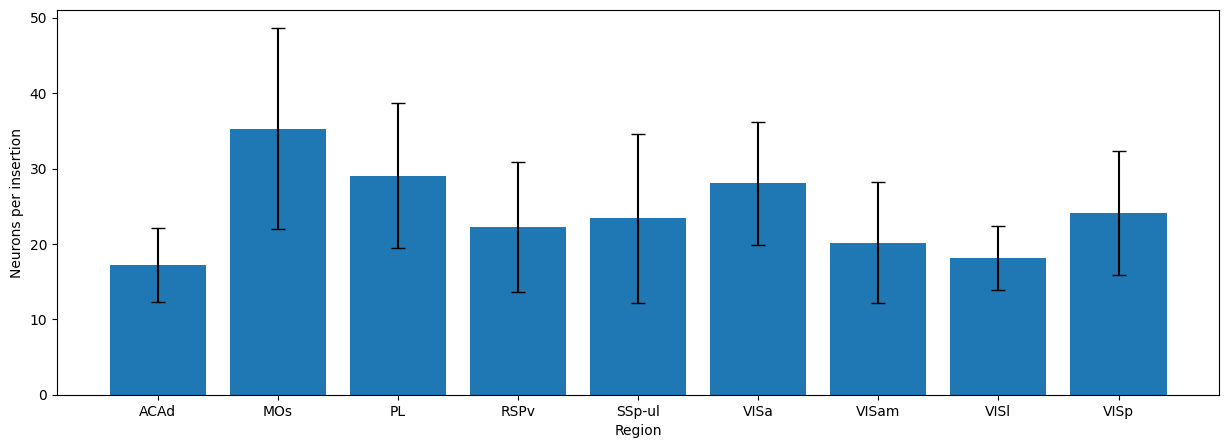

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(
    summary_stats["Beryl"],
    summary_stats["mean_count"],
    yerr=summary_stats["std_count"] / 2,
    capsize=5,
)
ax.set_xlabel("Region")
ax.set_ylabel("Neurons per insertion")

In [20]:
from ibl_info.swanson_plots import plot_vertical_swanson

In [39]:
br

BrainRegions(id=array([         0,        997,          8, ...,        -65,       -624,
       -304325711], shape=(2655,)), name=array(['void', 'root', 'Basic cell groups and regions', ...,
       'parafloccular sulcus (left)', 'Interpeduncular fossa (left)',
       'retina (left)'], shape=(2655,), dtype=object), acronym=array(['void', 'root', 'grey', ..., 'pfs', 'IPF', 'retina'],
      shape=(2655,), dtype=object), rgb=array([[  0,   0,   0],
       [255, 255, 255],
       [191, 218, 227],
       ...,
       [170, 170, 170],
       [170, 170, 170],
       [127,  46, 126]], shape=(2655, 3), dtype=uint8), level=array([0, 0, 1, ..., 3, 2, 1], shape=(2655,), dtype=uint16), parent=array([   nan,    nan,   997., ..., -1040., -1024.,  -997.], shape=(2655,)), order=array([   0,    0,    1, ..., 1324, 1325, 1326],
      shape=(2655,), dtype=uint16))

In [32]:
from ibl_info.swanson_plots import plot_swanson_vector

/Users/dkundu/mamba/envs/info-decom/lib/python3.10/site-packages/iblatlas/regions.py:663: RuntimeWarning: All-NaN slice encountered
  all_values = np.nanmedian(v, axis=0)


ValueError: Calling nonzero on 0d arrays is not allowed. Use np.atleast_1d(scalar).nonzero() instead. If the context of this error is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.

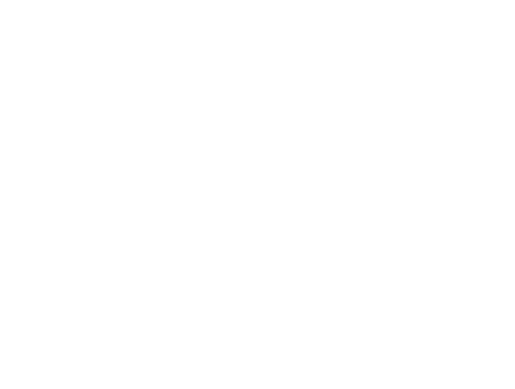

In [34]:
# from ibl_info.swanson_plots import plot_horizontal_swanson


# fig, ax = plt.subplots(figsize=(8, 8))

# plot_horizontal_swanson(
#     acronyms=np.asarray([["MOs", "APN"]]),
#     scores=[1, 1],
#     ax=ax,
#     cmap="viridis",
#     fontsize=7,
#     cbar_shrink=0.25,
#     annotate_kwargs={"annotate": True},
#     legend=False,
#     cbar_label="Average number of neurons",
# )

In [17]:
significances = df_with_both.groupby("Beryl")[["stim_dec", "prior_dec_ep"]].mean().reset_index()

In [ ]:
for idx in range(len(significances)):
    fig, ax = plt.subplots(figsize=(4, 4))
    values = significances.iloc[idx].values[1:]
    ax.bar(np.arange(2), values, edgecolor="k", color="#C9D5C0")
    ax.set_ylim([0, 0.2])
    ax.set_xticks(np.arange(2), ["Stim", "Prior"])
    ax.set_title(significances.iloc[idx]["Beryl"])
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.set_ylabel("$R^2$ over null")
    plt.show()

In [76]:
significances

,Beryl,stim_dec,prior_dec_ep
0,ACAd,0.04,0.046922
1,APN,0.06,0.036539
2,CP,0.03,0.049709
3,CUL4 5,0.03,0.046469
4,GRN,0.08,0.050190
5,IP,0.02,0.025878
6,IRN,0.01,0.034350
7,LGd,0.03,0.016409
8,MG,0.04,0.022478
9,MOs,0.04,0.052327


In [17]:
low_contrasts = [0.0625, 0.125, 0.25]  # 0 is essentially random yeah.

In [18]:
# remember -1 is right and 1 is left
# or rather we code 0 as right and 1 as left

eid = eids[1]

In [22]:
from ibl_info.prepare_data_pid import get_congruent_incongruent_intervals, prepare_ephys_data

In [125]:
# download this one and try everything out on it
# eids[1]

from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time

In [19]:
pids, probes = one.eid2pid(eid)

In [135]:
probes

['probe00']

### Throwing away non-responsive neurons

In [20]:
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

In [ ]:
# throw away non responsive neurons :


from ibl_info.old_code.run_single_session import clean_up_neurons

In [ ]:
# write new clean neuron code
# throw away neurons with nan values
# throw away neurons where it doesn't respond in 30 percent of trials


def cleaned_regions_single_region(
    region_data, percent_of_no_spikes_threshold=0.2, firing_rate_threshold=0, plot=False
):

    # we are not using the firing rate threshold at the moment
    # otherwise we can throw away neurons that fall below a certain percentage of the mean firing rate
    # code not here
    # we pass in regional data here anyways
    # differs from old function signature
    array_no_nans = region_data[~np.isnan(region_data).any(axis=1)]
    array_no_zeros = array_no_nans[~np.all(array_no_nans == 0, axis=1)]
    num_zeros = np.sum(array_no_zeros == 0, axis=1) / array_no_zeros.shape[1]
    keep_neurons = num_zeros <= 1 - percent_of_no_spikes_threshold
    array_filtered = array_no_zeros[keep_neurons]

    thrown_away_neurons = np.where(~keep_neurons)[0]

    if plot:
        fig, ax = plt.subplots(figsize=(5, 5))

        sns.heatmap(region_data, ax=ax, cmap="Greys")
        ax.set_title("cleaned")
        yticklabels = ax.get_yticklabels()
        for i, label in enumerate(yticklabels):
            if i in thrown_away_neurons:
                label.set_color("red")
        y_coordinates = np.arange(region_data.shape[0] + 1)

        xmin, xmax = ax.get_xlim()

        ax.hlines(
            y=y_coordinates,
            xmin=xmin,
            xmax=xmax,
            colors="black",
            linestyles="solid",
            lw=1,
        )

    return array_filtered

In [425]:
from decision_rnn.information_measures.processing import equipopulated_binning

In [ ]:
from ibl_info.utils import discretize, alternate_discretize

In [ ]:
spike_data = binned_spikes[0].T

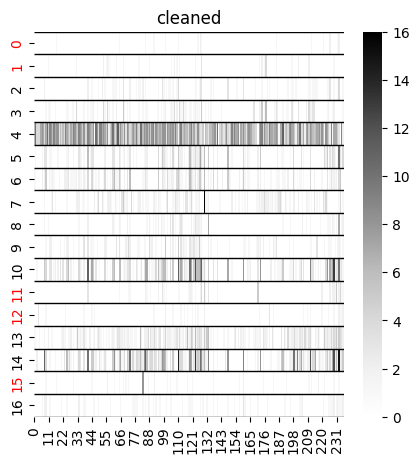

In [428]:
cleaned_data = cleaned_regions_single_region(spike_data, plot=True)
og_clean = np.copy(cleaned_data)

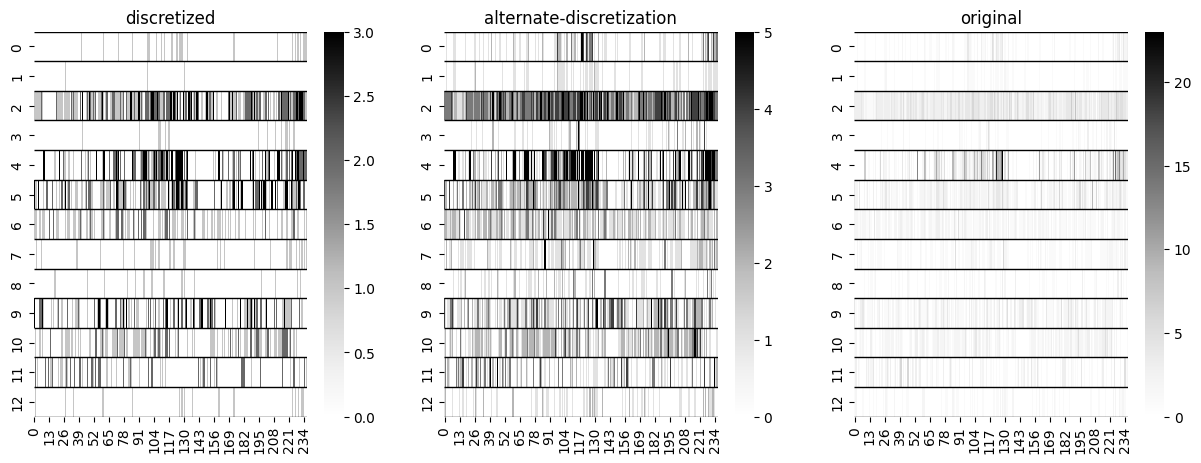

In [ ]:
discretized_data = discretize(cleaned_data, n_bins=5)
alternate_discretized_data = alternate_discretize(cleaned_data, n_bins=5)
fig, ax = plt.subplots(figsize=(15, 5), ncols=3)

sns.heatmap(discretized_data, ax=ax[0], cmap="Greys")
sns.heatmap(alternate_discretized_data, ax=ax[1], cmap="Greys")
sns.heatmap(cleaned_data, ax=ax[2], cmap="Greys")  # type: ignore
ax[0].set_title("discretized")
ax[1].set_title("alternate-discretization")
ax[2].set_title("original")

y_coordinates = np.arange(discretized_data.shape[0] + 1)
xmin, xmax = ax[0].get_xlim()

ax[0].hlines(
    y=y_coordinates,
    xmin=xmin,
    xmax=xmax,
    colors="black",
    linestyles="solid",
    lw=1,
)
ax[1].hlines(
    y=y_coordinates,
    xmin=xmin,
    xmax=xmax,
    colors="black",
    linestyles="solid",
    lw=1,
)
ax[2].hlines(
    y=y_coordinates,
    xmin=xmin,
    xmax=xmax,
    colors="black",
    linestyles="solid",
    lw=1,
)

In [429]:
from ibl_info.measures import information_measures as info

In [430]:
def compute_mutual_information(neural_data, decoding_variable):
    mi_data = np.zeros((neural_data.shape[0]))
    for idx in range(len(mi_data)):
        mi_data[idx] = info.corrected_mutual_information(  # type: ignore
            source=neural_data[idx, :], target=decoding_variable, unbiased_measure="quadratic"
        )
    return mi_data

In [431]:
mi_data = compute_mutual_information(alternate_discretized_data, decoding_variable_all)

In [432]:
np.mean(mi_data)

np.float64(0.0032156549166857027)

In [433]:
mi_data = compute_mutual_information(discretized_data, decoding_variable_all)

In [434]:
np.mean(mi_data)

np.float64(0.0024482945303600815)

In [435]:
def compute_pid(sources, data, targets, unbiased_measure="quadratic"):
    pid_information = np.zeros((len(sources), 4))  # neuronsC2 x 4
    for idx in tqdm(
        range(len(sources)), desc="Running for all sources", leave=False
    ):  # this is the place to introduce parallelization
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(data[s1, :], dtype=np.int32)
        X2 = np.asarray(data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = info.corrected_pid(sourcea=X1, sourceb=X2, target=Y, unbiased_measure=unbiased_measure)  # type: ignore
        pid_information[idx, :] = u1, u2, red, syn

    return pid_information

In [436]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids = []
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])

    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids

In [437]:
sources = generate_source_ids(cleaned_data.shape[0])

In [44]:
flag_stim = df["stim_dec_sig"] == 1
flag_prior = df["prior_dec_ep_sig"] == 1
flag_choice = df["choice_dec_sig"] == 1

### Check if subsampling works

In [21]:
eid = eids[0]

In [24]:
from ibl_info.selective_decomposition import filter_eids


one = ONE()
unit_df = bwm_units(one)
selective_eids = filter_eids(unit_df, "VISp")

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [26]:
eid = selective_eids[0]

In [27]:
from ibl_info.selective_decomposition import run_subsampled_congruent

In [28]:
checkC = run_subsampled_congruent(eid, "stim", one, "VISp")

[0, 0.2]
Total selected indices for subsampling: 49

Running analysis for stim - VISp - subsampled
Region found VISp, 12


In [32]:
from ibl_info.selective_decomposition import prepare_neural_data


allpidpickle = prepare_neural_data(eid, "stim", one, "VISp")

[0, 0.2]
Running analysis for stim - VISp - all
Region found VISp, 12


Running analysis for stim - VISp - congruent
Region found VISp, 12


Running analysis for stim - VISp - incongruent
Region found VISp, 12


In [21]:
from glob import glob

In [22]:
files = glob("../data/generated/datacount/*.pkl")
region_names = np.asarray([r.rsplit("_stim")[-2].rsplit("_")[-1] for r in files])

In [23]:
region_names[0], files[0]

(np.str_('SNr'),
 '../data/generated/datacount/selective_decomposition_SNr_stim_datacount.pkl')

In [24]:
def compute_stats(data):
    all_count = []
    cong_count = []
    incon_count = []
    for eid in data.keys():
        all_count.append(data[eid]["all"])
        cong_count.append(data[eid]["congruent"])
        incon_count.append(data[eid]["incongruent"])

    all_count = np.asarray(all_count)
    cong_count = np.asarray(cong_count)
    incon_count = np.asarray(incon_count)

    stats = np.zeros((3, 2))

    stats[0, 0] = np.mean(all_count)
    stats[0, 1] = np.std(all_count) / 2

    stats[1, 0] = np.mean(cong_count)
    stats[1, 1] = np.std(cong_count) / 2

    stats[2, 0] = np.mean(incon_count)
    stats[2, 1] = np.std(incon_count) / 2

    eid_all = len(np.where(all_count != 0)[0])
    eid_cong = len(np.where(cong_count != 0)[0])
    eid_incon = len(np.where(incon_count != 0)[0])

    return stats, np.asarray([eid_all, eid_cong, eid_incon])

In [25]:
for idx, filename in enumerate(files):
    region = region_names[idx]
    if region not in regions_of_interest:
        continue

    with open(filename, "rb") as f:
        data = pkl.load(f)

    colors = ["#a2c4e3", "#ffc080", "#9bcd9b"]
    stats, counts = compute_stats(data)
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.bar(np.arange(3), stats[:, 0], yerr=stats[:, 1], edgecolor="k", color=colors, capsize=2)
    ax.set_title(region)
    ax.set_xticks(np.arange(3), ["All", "Congruent", "Incongruent"])
    ax.set_ylim([0, 40])
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)
    ax.set_title("Usable number of recordings (after thresholding)")
    ax.set_ylabel("Number of recordings")
    plt.savefig(
        f"../reports/figures/insertions/{region}_insertions",
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close()
    print(counts[0], region)

5 SNr
48 SCm
13 RN
6 SSp-ul
80 MRN
14 ACAd
29 VPM
14 GRN
27 PAG
28 VISp
15 SIM
22 IRN
21 CUL4 5
17 PRNr
56 CP
19 IP
17 LGd
30 MOs
42 APN
15 ZI
12 PL
12 MG
7 PRNc
12 PPN
4 PGRN


### Single cell results


In [177]:
from brainwidemap.single_cell_stats.single_cell_Working_example_stimulus import BWM_stim_test

In [178]:
# okay how

# for each eid in our dataset
# combine probes
# do the test in the interval we want
# save results

# load them up
# intersect with regions of interest
# count raw numbers that exist -> from unit_df
# count number of significant recordings

In [13]:
# intersect with units_df to get some idea
from glob import glob

In [14]:
brainreg = BrainRegions()

In [209]:
eids_csv_list = glob("../data/processed/singlecellresults/*.csv")
eids = [e.rsplit("_")[-1].rstrip(".csv") for e in eids_csv_list]

In [210]:
def compute_summary(df):

    # Group by 'area_label' and count p_values less than 0.05
    count_less_than_0_05 = (
        df.groupby("area_label")["p_value"]
        .apply(lambda x: (x < 0.05).sum())
        .reset_index(name="count_less_than_0.05")
    )

    # Group by 'area_label' and get the total count of p_values
    total_count = df.groupby("area_label")["p_value"].count().reset_index(name="total_count")

    # Merge the two dataframes
    merged_df = pd.merge(count_less_than_0_05, total_count, on="area_label")
    merged_df["fraction_less_than_0.05"] = (
        merged_df["count_less_than_0.05"] / merged_df["total_count"]
    )
    merged_df["region_name"] = merged_df["area_label"].apply(
        lambda x: brainreg.id2acronym([x], mapping="Beryl")[0]
    )

    return merged_df

In [211]:
global_merge = []
for idx in range(len(eids_csv_list)):
    df = pd.read_csv(eids_csv_list[idx])
    df.drop("Unnamed: 0", axis=1, inplace=True)
    unit_df_subset = unit_df[unit_df["eid"] == eids[idx]]

    assert unit_df_subset["cluster_id"].isin(df["QC_cluster_id"]).sum() == len(unit_df_subset)

    regions = brainreg.id2acronym(df["area_label"], mapping="Beryl")

    # now what
    region_flag = np.isin(regions, regions_of_interest)
    df = df[region_flag]

    merged_df = compute_summary(df)
    merged_df["eid"] = eids[idx]
    global_merge.append(merged_df)

In [212]:
global_merge = pd.concat(global_merge)

In [226]:
A = (
    global_merge.groupby("region_name")["fraction_less_than_0.05"]
    .agg(["mean", "std"])
    .reset_index()
)

In [228]:
A

,region_name,mean,std
0,ACAd,0.143149,0.132235
1,APN,0.098327,0.097885
2,CP,0.089428,0.071131
3,CUL4 5,0.059536,0.092585
4,GRN,0.120527,0.128899
5,IP,0.109030,0.113825
6,IRN,0.077009,0.080972
7,LGd,0.060660,0.114346
8,MG,0.094453,0.116617
9,MOs,0.095317,0.121093


Text(0.5, 1.0, 'Single cell stimulus results')

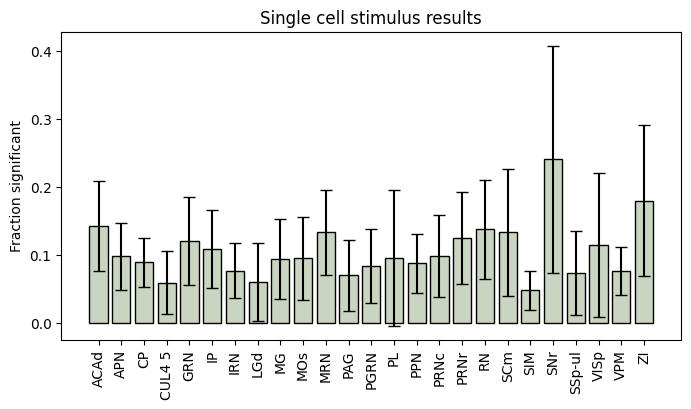

In [230]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(A)), A["mean"], edgecolor="k", yerr=A["std"] / 2, color="#C9D5C0", capsize=4)
ax.set_xticks(np.arange(len(A)), A["region_name"].values, rotation=90)
ax.set_ylabel("Fraction significant")
ax.set_title("Single cell stimulus results")

In [215]:
MEIDS = units_regions_of_interest.eid.unique()

In [216]:
eids = np.asarray(eids)

In [217]:
np.sum(np.isin(eids, MEIDS))

np.int64(312)

### Single cell firing rates

In [15]:
EIDS = units_regions_of_interest["eid"].unique()

In [111]:
session_id = EIDS[1]

In [112]:
from ibl_info.prepare_data_pid import get_window


pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

# i only want one region normally
# or maybe we check how many regions this animal has
# that makes sense

epoch = "stim"
window = get_window(epoch)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

# for now we are looking at just (stimulus interval)
# we know the order
labels = ["all", "congruent", "incongruent"]
intervals, decoding_variables = get_congruent_incongruent_intervals(trials, epoch)

In [108]:
from ibl_info.prepare_data_pid import get_contrast_intervals


intervals_contrast = get_contrast_intervals(trials, epoch)

In [109]:
from brainbox.singlecell import firing_rate
from ibl_info.prepare_data_pid import (
    get_congruent_incongruent_intervals,
    get_window,
    get_contrast_intervals,
)

In [120]:
region = "ACAd"

In [133]:
from ibl_info.firing_rates import get_spike_data_in_binsv2

In [134]:
trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

# for now we are looking at just (stimulus interval)
# we know the order
intervals_by_congruency, _ = get_congruent_incongruent_intervals(trials, epoch)
intervals_by_contrast = get_contrast_intervals(trials, epoch)
# also compute firing rate using the entire window

binned_spikes = []
for interval in intervals_by_congruency:
    binned, _, _, _, firing_rate_a = get_spike_data_in_binsv2(spikes, clusters, interval, regions)
    binned_spikes.append(binned)

for interval in intervals_by_contrast:
    binned, _, _, _, firing_rate_b = get_spike_data_in_binsv2(spikes, clusters, interval, regions)
    binned_spikes.append(binned)

In [ ]:
# get mean-spike rates for each condition
# this should be easy

spike_rates = np.zeros(
    (len(binned_spikes) + 1, len(binned_spikes[0]))
)  # one to add the global rate
time_window = get_window("stim")

for i, binned_neuron in enumerate(binned_spikes):
    binned_rate = binned_neuron / time_window[1] - time_window[0]
    spike_rates[i, :] = np.mean(binned_rate, axis=1)

spike_rates[-1, :] = firing_rate_b

<Axes: >

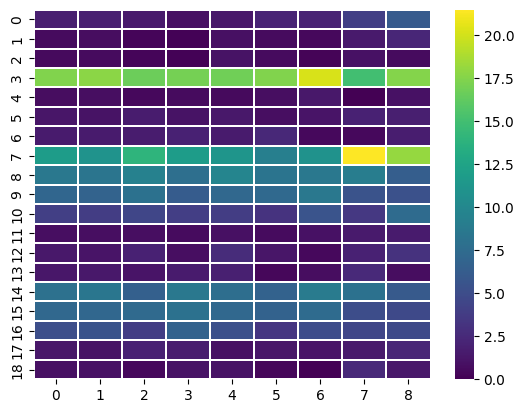

In [209]:
sns.heatmap(spike_rates.T, cmap="viridis", linecolor="white", linewidths=0.25)
# save this for each eid
# then we can compute statistics (I guess)

In [212]:
spike_rates.shape

(9, 19)

In [211]:
np.allclose(firing_rate_a, firing_rate_b)  # type: ignore

True

### Filtering, equipopulated binning and also subsampling

In [16]:
eids = units_regions_of_interest["eid"].unique()

In [17]:
session_id = eids[0]

In [18]:
trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

# for now we are looking at just (stimulus interval)
# we know the order
labels = ["all", "congruent", "incongruent"]

In [19]:
from ibl_info.prepare_data_pid import get_new_cinc_intervals

In [20]:
trials_df = trials.copy()

In [21]:
intervals, stimside, congruent_flags, incongruent_flags = get_new_cinc_intervals(trials_df, "stim")

In [22]:
from ibl_info.selective_decomposition import run_analysis_single_session

In [23]:
unit_df[unit_df["eid"] == eids[0]].Beryl.unique()[
    np.isin(unit_df[unit_df["eid"] == eids[0]].Beryl.unique(), regions_of_interest)
]

array(['ACAd', 'MOs', 'PL'], dtype=object)

Region found MOs, 69
Region found MOs, 69


<BarContainer object of 23 artists>

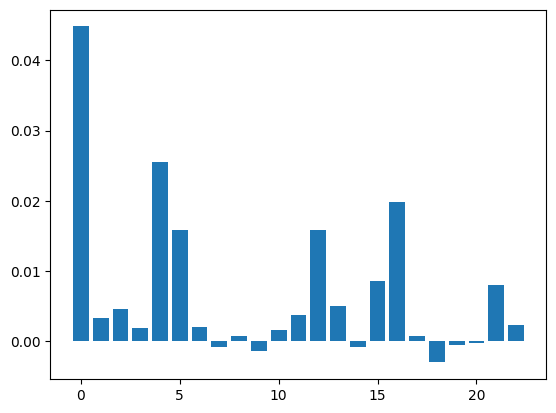

In [263]:
plt.bar(np.arange(sps.shape[0]), info_pik["all"]["mutual_information"])

<BarContainer object of 253 artists>

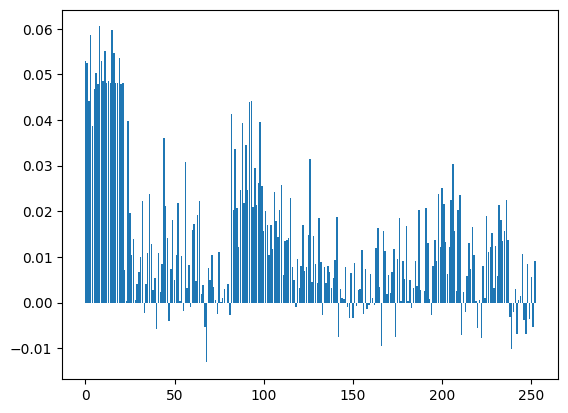

In [264]:
plt.bar(
    np.arange(253),
    info_pik["all"]["trivariate"].reshape(
        -1,
    ),
)

np.float64(0.003937483958155683)

In [29]:
region = "ACAd"

In [30]:
# check subsampling stuff

In [96]:
info_pik, congruent_spikes, congruent_trials, incongruent_trials = run_analysis_single_session(
    session_id, "stim", one, region, discretize_method=1
)

Region found ACAd, 19
Region found ACAd, 19


In [97]:
left_fraction = np.sum(incongruent_trials == 1) / len(incongruent_trials)

# we want to ensure similar fraction for congruent subsampling
left_congruent = np.where(congruent_trials == 1)[0]
right_congruent = np.where(congruent_trials == 0)[0]

In [98]:
import random

In [99]:
n_left_subsample = np.round(left_fraction * len(incongruent_trials))
n_right_subsample = len(incongruent_trials) - n_left_subsample

In [100]:
n_right_subsample

np.float64(50.0)

In [101]:
# now we need to do the actual subsampling

In [102]:
from ibl_info.selective_decomposition import compute_condition


left_fraction = np.sum(incongruent_trials == 1) / len(incongruent_trials)

# we want to ensure similar fraction for congruent subsampling
left_congruent = np.where(congruent_trials == 1)[0]
right_congruent = np.where(congruent_trials == 0)[0]

n_left_subsample = int(np.round(left_fraction * len(incongruent_trials)))
n_right_subsample = int(len(incongruent_trials) - n_left_subsample)

sampled_mi = []
sampled_pid = []
sampled_joint = []
for repeats in range(10):

    # now we need to do the actual subsampling
    selected_indices_left = np.random.choice(left_congruent, n_left_subsample, replace=False)
    selected_indices_right = np.random.choice(right_congruent, n_right_subsample, replace=False)

    selected_indices = np.concatenate((selected_indices_left, selected_indices_right))
    subsampled_trials = congruent_trials[selected_indices]
    subsampled_spikes = congruent_spikes[:, selected_indices]

    info_ = compute_condition(subsampled_trials, subsampled_spikes)
    sampled_mi.append(info_["mutual_information"])
    sampled_pid.append(info_["pid"])
    sampled_joint.append(info_["trivariate"])

# average
sampled_mi = np.asarray(sampled_mi)
sampled_pid = np.asarray(sampled_pid)
sampled_joint = np.asarray(sampled_joint)

In [103]:
A = np.mean(sampled_pid, axis=0)

In [104]:
info_pik["all"]["pid"].shape
A.shape

(15, 4)

In [105]:
np.mean(info_pik["all"]["pid"], axis=0)

array([0.00357495, 0.00469571, 0.00103511, 0.00214449])

In [106]:
np.mean(A, axis=0)

array([9.27940140e-05, 7.50290491e-03, 2.80321660e-03, 3.44851348e-03])

In [107]:
np.mean(info_pik["congruent"]["pid"], axis=0)

array([0.00479223, 0.00629451, 0.00378179, 0.00400735])

In [108]:
np.mean(info_pik["incongruent"]["pid"], axis=0)

array([-0.00727505, -0.00161947, -0.0011566 ,  0.01067171])